In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay

import load.load_dataset as ds
import load.load_net as nt

import joblib

In [28]:
def plot_roc(y_val, result1, result2, result3, result4, result5, result6, dataset_name, class_idx = None):
    y_val_labels = y_val.detach().numpy().argmax(axis=1)

    roc1 = roc_auc_score(y_val_labels, result1['pred_proba'][0][:,1])
    fpr1, tpr1, _ = roc_curve(y_val_labels, result1['pred_proba'][0][:,1])

    roc2 = roc_auc_score(y_val_labels, result2['pred_proba'][0][:,1])
    fpr2, tpr2, _ = roc_curve(y_val_labels, result2['pred_proba'][0][:,1])

    roc3 = roc_auc_score(y_val_labels, result3['pred_proba'][0][:,1])
    fpr3, tpr3, _ = roc_curve(y_val_labels, result3['pred_proba'][0][:,1])

    roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
    fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])

    roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
    fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])

    roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
    fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    plt.figure(figsize=(6,6))
    ax[0].set_title('SmallNN')
    ax[0].plot(fpr1, tpr1, color='black', label=f'Small - {roc1:.4f}')
    ax[0].plot(fpr4, tpr4, color='red', label=f'Reg 0.1 dropout - {roc4:.4f}')
    ax[0].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend()

    ax[1].set_title('DeeperNN')
    ax[1].plot(fpr2, tpr2, color='black', label=f'Deeper - {roc2:.4f}')
    ax[1].plot(fpr5, tpr5, color='red', label=f'Reg 0.1 dropout - {roc5:.4f}')
    ax[1].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend()

    ax[2].set_title('ShallowNN')
    ax[2].plot(fpr3, tpr3, color='black', label=f'Shallow - {roc3:.4f}')
    ax[2].plot(fpr6, tpr6, color='red', label=f'Reg 0.1 dropout - {roc6:.4f}')
    ax[2].plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].legend()

    plt.tight_layout()
    plt.show()


In [29]:
def plot_conf_matrix(y_val, result1, result2, result3, title = ['', '', '']):
    cm1 = result1['confusion_matrix'][0]
    cm2 = result2['confusion_matrix'][0]
    cm3 = result3['confusion_matrix'][0]
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
    ax[0].set_title(title[0])
    ax[1].set_title(title[1])
    ax[2].set_title(title[2])
    disp1.plot(cmap=plt.cm.Blues, ax=ax[0])
    disp2.plot(cmap=plt.cm.Blues, ax=ax[1])
    disp3.plot(cmap=plt.cm.Blues, ax=ax[2])
    plt.show()

In [30]:
def eval_net(dataset_name, model_name, verbose = False):

    history = joblib.load(f'./models/histories/{dataset_name}_{model_name}_history.joblib')
    results = joblib.load(f'./models/results/{dataset_name}_{model_name}_results.joblib')

    if verbose:
        axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))
        fig, ax = plt.subplots(1, 2, figsize = [12,5])
        ax[0].plot(axis, history['train_loss'], label='Train Loss')
        ax[0].plot(axis, history['val_loss'], label='Val Loss')
        ax[0].set_title('Loss')
        ax[0].legend()

        ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
        ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
        ax[1].set_title('Accuracy')
        ax[1].legend()
        plt.tight_layout()
        plt.show()
        print(results['classification_report'][0])
    return results


# ADULT

structure of the nets for dataset adult:

In [31]:
read = joblib.load('./load/nets/model_adult_dict.joblib')
read

{'model1': smallNN(
   (linear1): Linear(in_features=97, out_features=256, bias=True)
   (sigmoid1): ReLU()
   (linear2): Linear(in_features=256, out_features=128, bias=True)
   (sigmoid2): ReLU()
   (linear3): Linear(in_features=128, out_features=64, bias=True)
   (sigmoid3): ReLU()
   (linear4): Linear(in_features=64, out_features=32, bias=True)
   (sigmoid4): ReLU()
   (linear5): Linear(in_features=32, out_features=2, bias=True)
   (softmax): Softmax(dim=None)
 ),
 'model2': deeperNN(
   (linear1): Linear(in_features=97, out_features=1024, bias=True)
   (relu1): ReLU()
   (linear2): Linear(in_features=1024, out_features=512, bias=True)
   (relu2): ReLU()
   (linear3): Linear(in_features=512, out_features=128, bias=True)
   (relu3): ReLU()
   (linear4): Linear(in_features=128, out_features=64, bias=True)
   (relu4): ReLU()
   (linear5): Linear(in_features=64, out_features=32, bias=True)
   (relu5): ReLU()
   (linear6): Linear(in_features=32, out_features=2, bias=True)
   (softmax): S

In [32]:
dataset_name = "adult"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

adult_smallNN = eval_net(dataset_name, 'model1')
adult_deeperNN = eval_net(dataset_name, 'model2')
adult_shallowNN = eval_net(dataset_name, 'model3')

adult_regSmallNN = eval_net(dataset_name, 'model1r')
adult_regDeeperNN = eval_net(dataset_name, 'model2r')
adult_regShallowNN = eval_net(dataset_name, 'model3r')

(36177, 12) (8045, 12) (1000, 12)


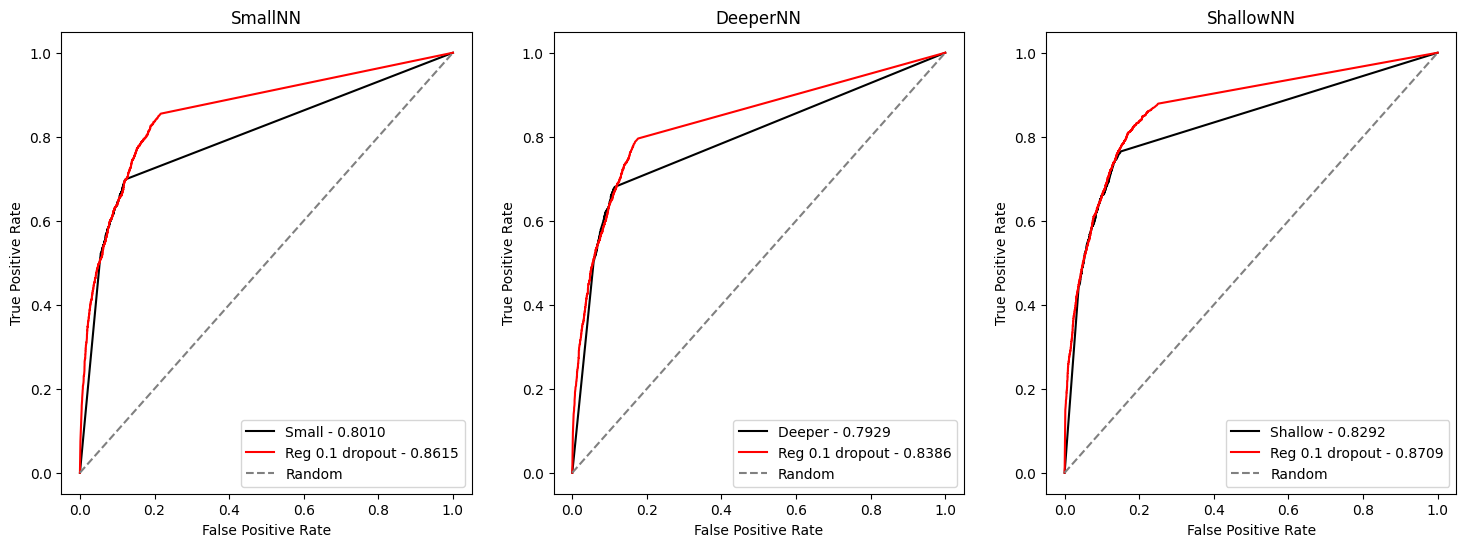

<Figure size 600x600 with 0 Axes>

In [33]:
plot_roc(y_val, adult_smallNN, adult_deeperNN, adult_shallowNN, adult_regSmallNN, adult_regDeeperNN, adult_regShallowNN, dataset_name)

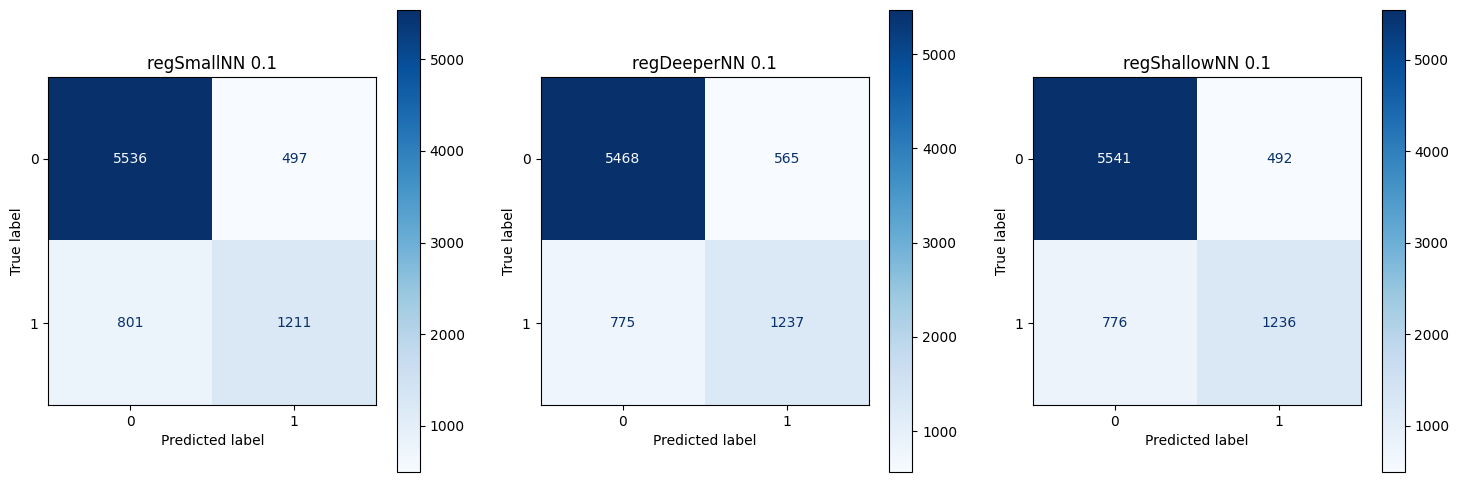

In [34]:
plot_conf_matrix(y_val, adult_regSmallNN, adult_regDeeperNN, adult_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# BANK

In [35]:
dataset_name = "bank"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

bank_smallNN = eval_net(dataset_name, 'model1')
bank_deeperNN = eval_net(dataset_name, 'model2')
bank_shallowNN = eval_net(dataset_name, 'model3')

bank_regSmallNN = eval_net(dataset_name, 'model1r')
bank_regDeeperNN = eval_net(dataset_name, 'model2r')
bank_regShallowNN = eval_net(dataset_name, 'model3r')

(36168, 14) (8043, 14) (1000, 14)


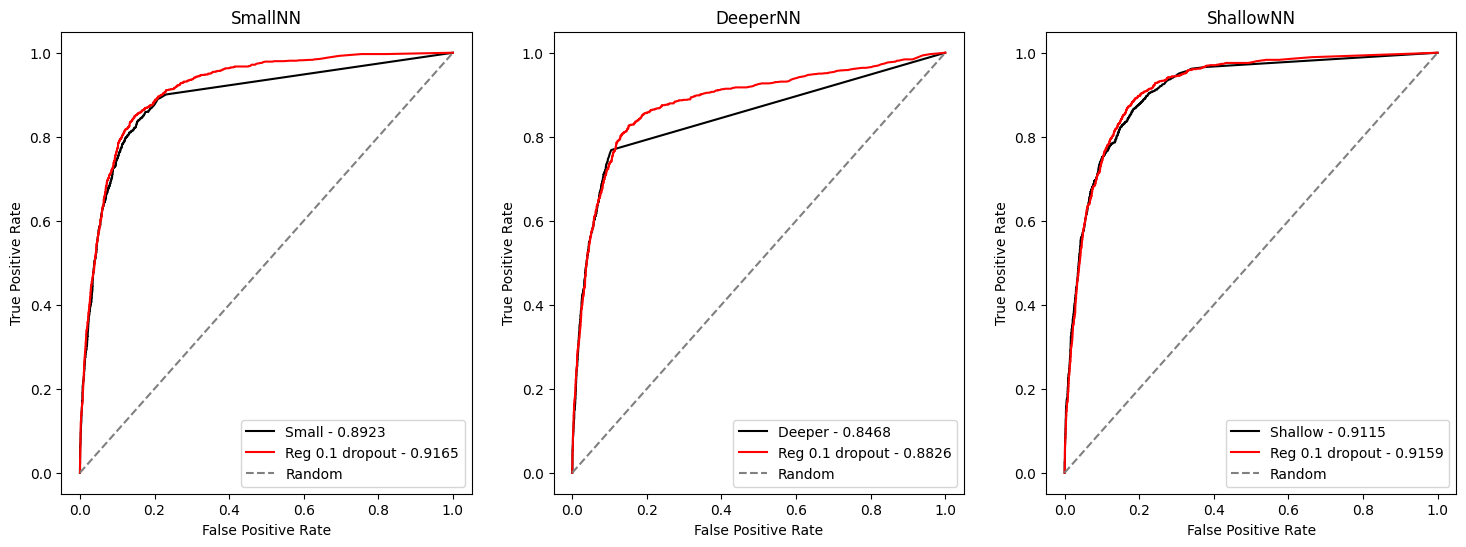

<Figure size 600x600 with 0 Axes>

In [36]:
plot_roc(y_val, bank_smallNN, bank_deeperNN, bank_shallowNN, bank_regSmallNN, bank_regDeeperNN, bank_regShallowNN, dataset_name)

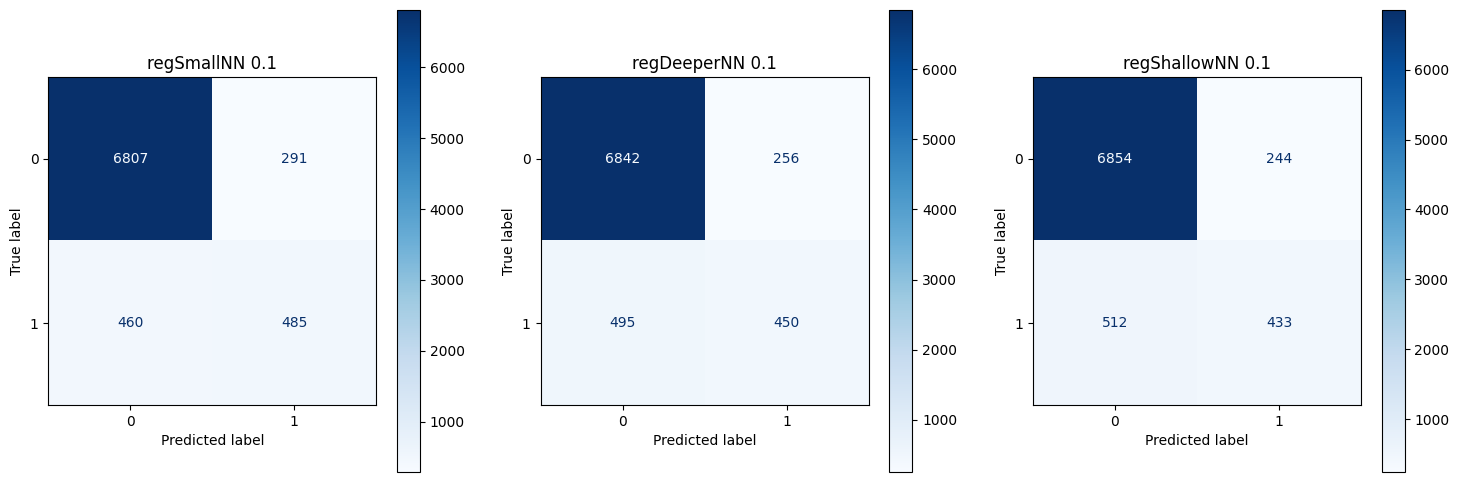

In [37]:
plot_conf_matrix(y_val, bank_regSmallNN, bank_regDeeperNN, bank_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# BEANS

In [38]:
dataset_name = "beans"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

beans_smallNN = eval_net(dataset_name, 'model1')
beans_deeperNN = eval_net(dataset_name, 'model2')
beans_shallowNN = eval_net(dataset_name, 'model3')

beans_regSmallNN = eval_net(dataset_name, 'model1r')
beans_regDeeperNN = eval_net(dataset_name, 'model2r')
beans_regShallowNN = eval_net(dataset_name, 'model3r')

(10888, 7) (2223, 7) (500, 7)


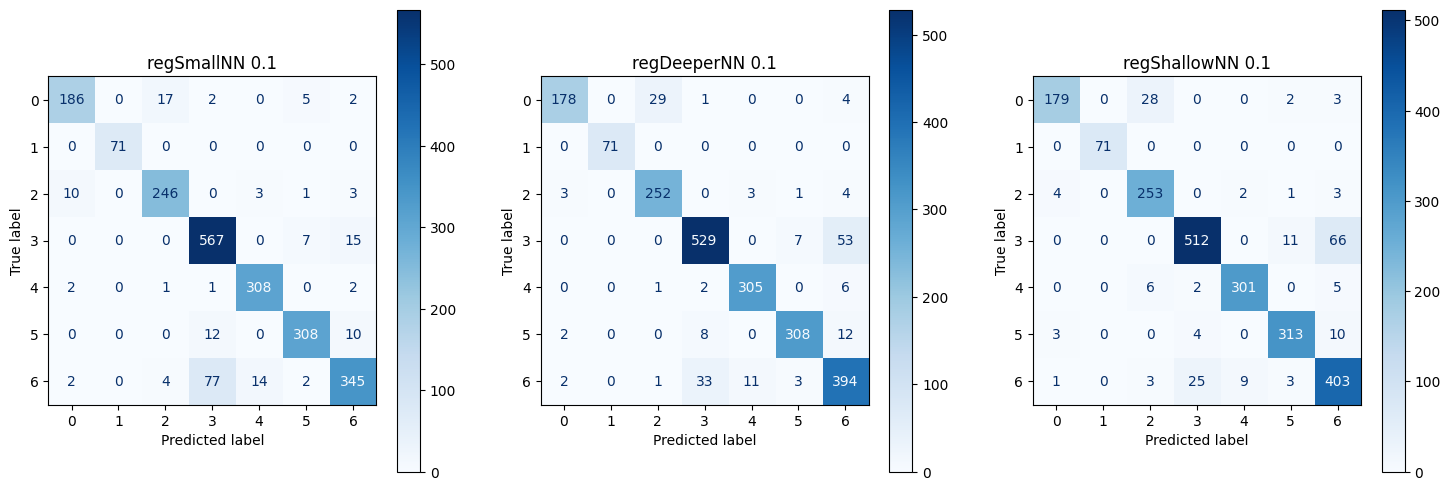

In [39]:
plot_conf_matrix(y_val, beans_regSmallNN, beans_regDeeperNN, beans_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# CANCER

In [40]:
dataset_name = "cancer"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

cancer_smallNN = eval_net(dataset_name, 'model1')
cancer_deeperNN = eval_net(dataset_name, 'model2')
cancer_shallowNN = eval_net(dataset_name, 'model3')

cancer_regSmallNN = eval_net(dataset_name, 'model1r')
cancer_regDeeperNN = eval_net(dataset_name, 'model2r')
cancer_regShallowNN = eval_net(dataset_name, 'model3r')

(397, 15) (121, 15) (50, 15)


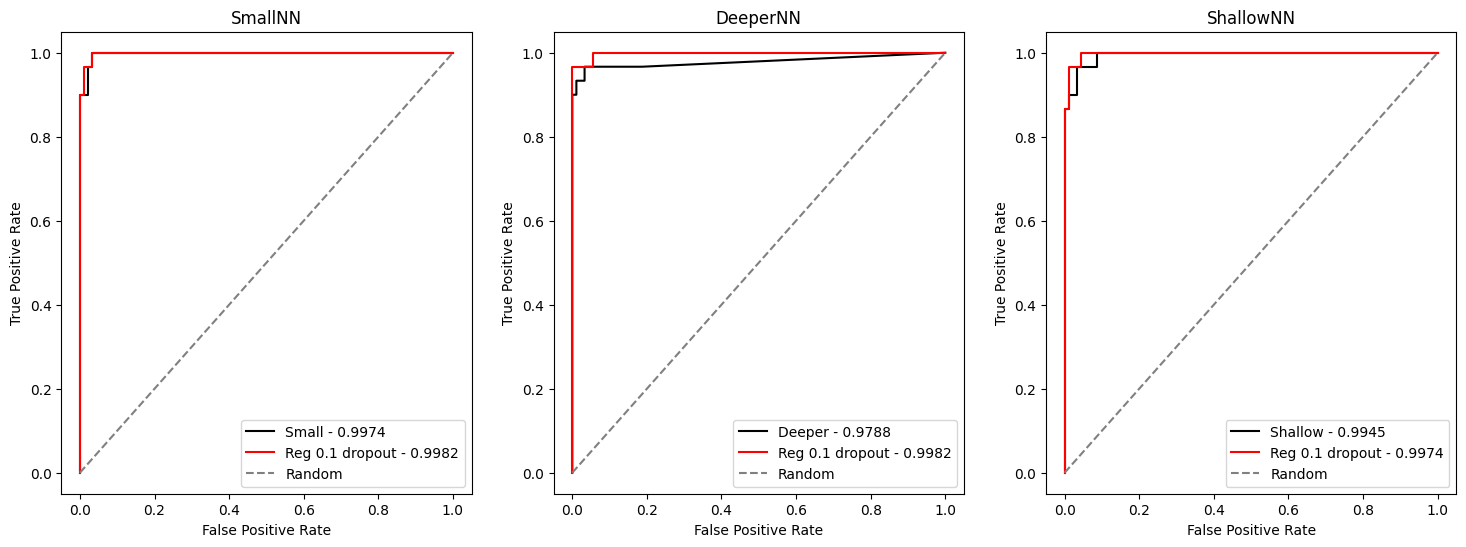

<Figure size 600x600 with 0 Axes>

In [41]:
plot_roc(y_val, cancer_smallNN, cancer_deeperNN, cancer_shallowNN, cancer_regSmallNN, cancer_regDeeperNN, cancer_regShallowNN, dataset_name)

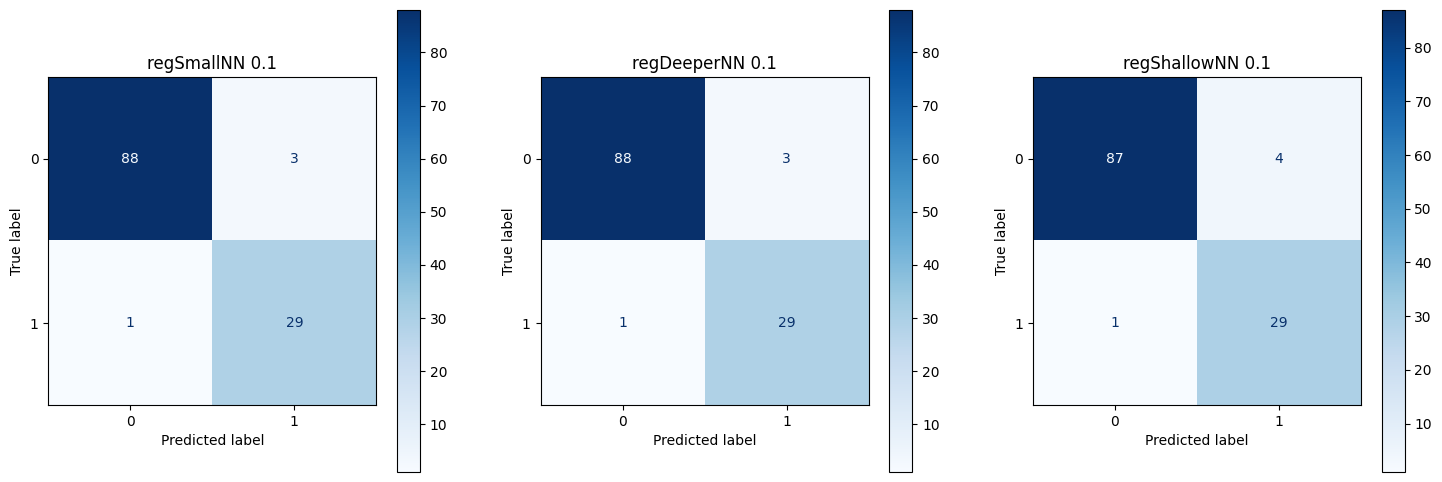

In [42]:
plot_conf_matrix(y_val, cancer_regSmallNN, cancer_regDeeperNN, cancer_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])


# HELOC

In [43]:
dataset_name = "heloc"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

heloc_smallNN = eval_net(dataset_name, 'model1')
heloc_deeperNN = eval_net(dataset_name, 'model2')
heloc_shallowNN = eval_net(dataset_name, 'model3')

heloc_regSmallNN = eval_net(dataset_name, 'model1r')
heloc_regDeeperNN = eval_net(dataset_name, 'model2r')
heloc_regShallowNN = eval_net(dataset_name, 'model3r')

(8367, 16) (1592, 16) (500, 16)


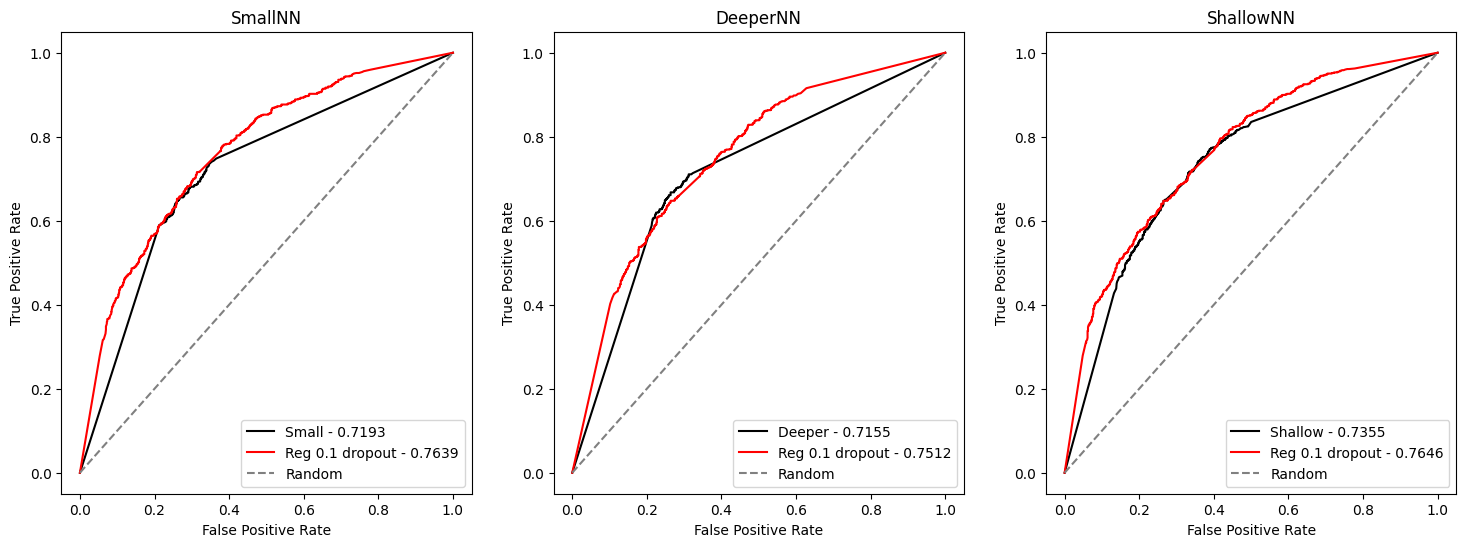

<Figure size 600x600 with 0 Axes>

In [44]:
plot_roc(y_val, heloc_smallNN, heloc_deeperNN, heloc_shallowNN, heloc_regSmallNN, heloc_regDeeperNN, heloc_regShallowNN, dataset_name)

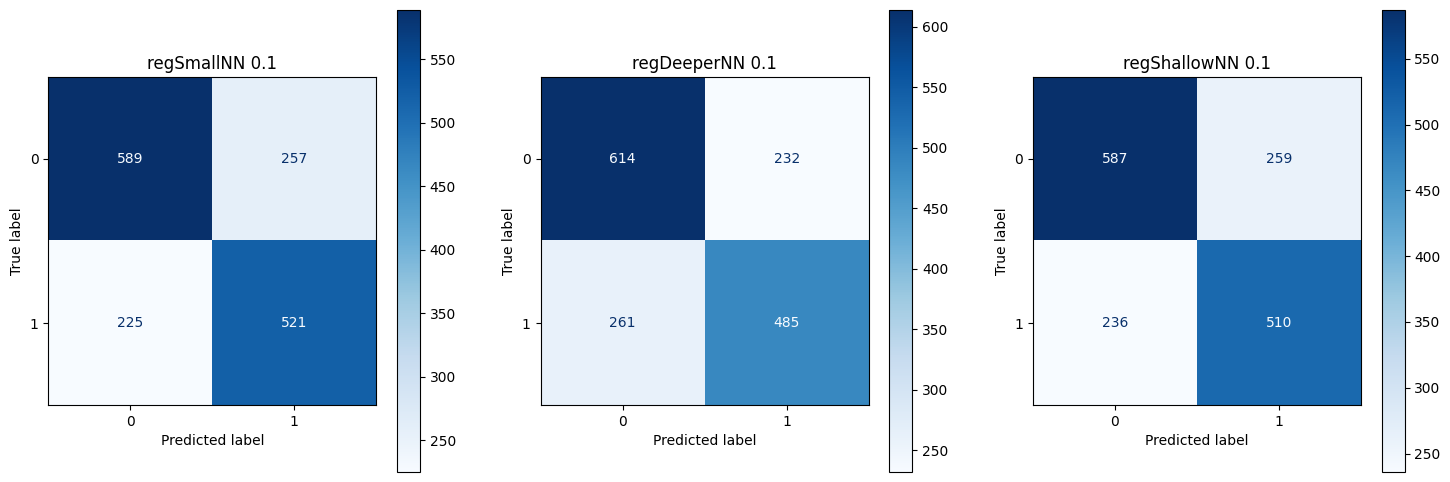

In [45]:
plot_conf_matrix(y_val, heloc_regSmallNN, heloc_regDeeperNN, heloc_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# MUSHROOMS

In [46]:
dataset_name = "mushroom"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

mushroom_smallNN = eval_net(dataset_name, 'model1')
mushroom_deeperNN = eval_net(dataset_name, 'model2')
mushroom_shallowNN = eval_net(dataset_name, 'model3')

mushroom_regSmallNN = eval_net(dataset_name, 'model1r')
mushroom_regDeeperNN = eval_net(dataset_name, 'model2r')
mushroom_regShallowNN = eval_net(dataset_name, 'model3r')

(6498, 21) (1225, 21) (400, 21)


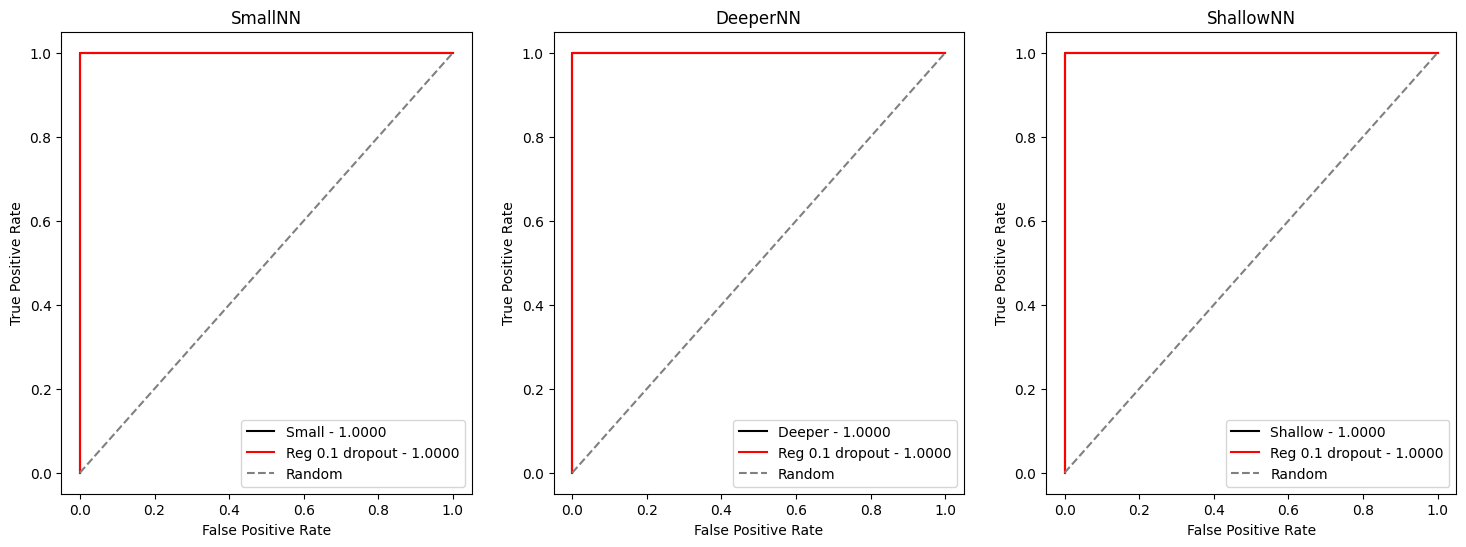

<Figure size 600x600 with 0 Axes>

In [47]:
plot_roc(y_val, mushroom_smallNN, mushroom_deeperNN, mushroom_shallowNN, mushroom_regSmallNN, mushroom_regDeeperNN, mushroom_regShallowNN, dataset_name)

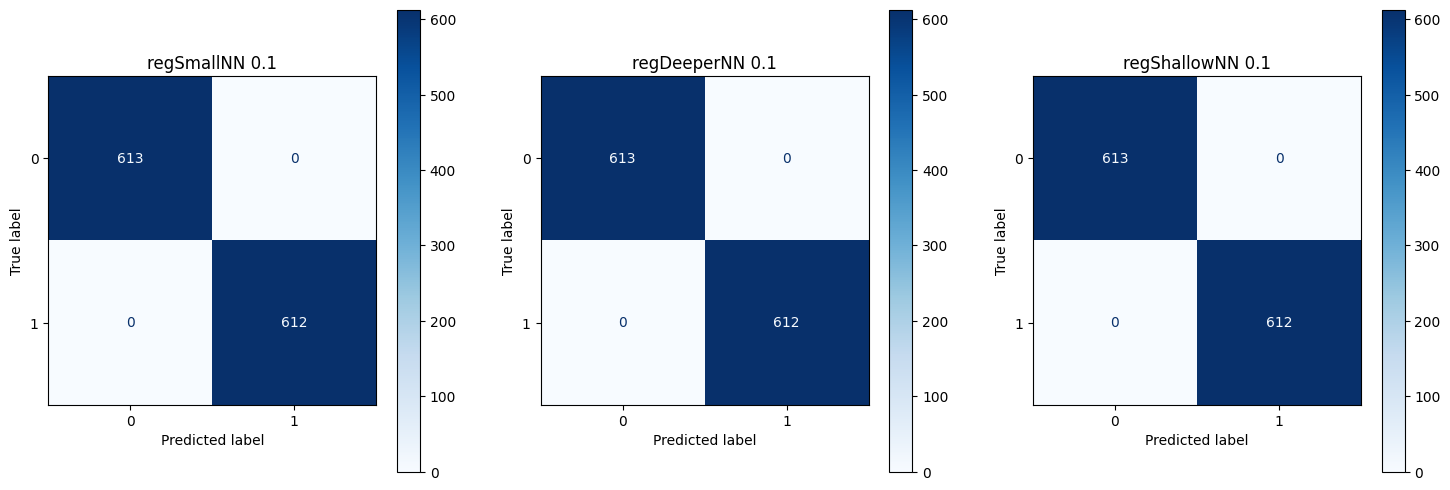

In [48]:
plot_conf_matrix(y_val, mushroom_regSmallNN, mushroom_regDeeperNN, mushroom_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# OCEAN

In [49]:
dataset_name = "ocean"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

ocean_smallNN = eval_net(dataset_name, 'model1')
ocean_deeperNN = eval_net(dataset_name, 'model2')
ocean_shallowNN = eval_net(dataset_name, 'model3')

ocean_regSmallNN = eval_net(dataset_name, 'model1r')
ocean_regDeeperNN = eval_net(dataset_name, 'model2r')
ocean_regShallowNN = eval_net(dataset_name, 'model3r')

(109259, 8) (30328, 8) (10000, 8)


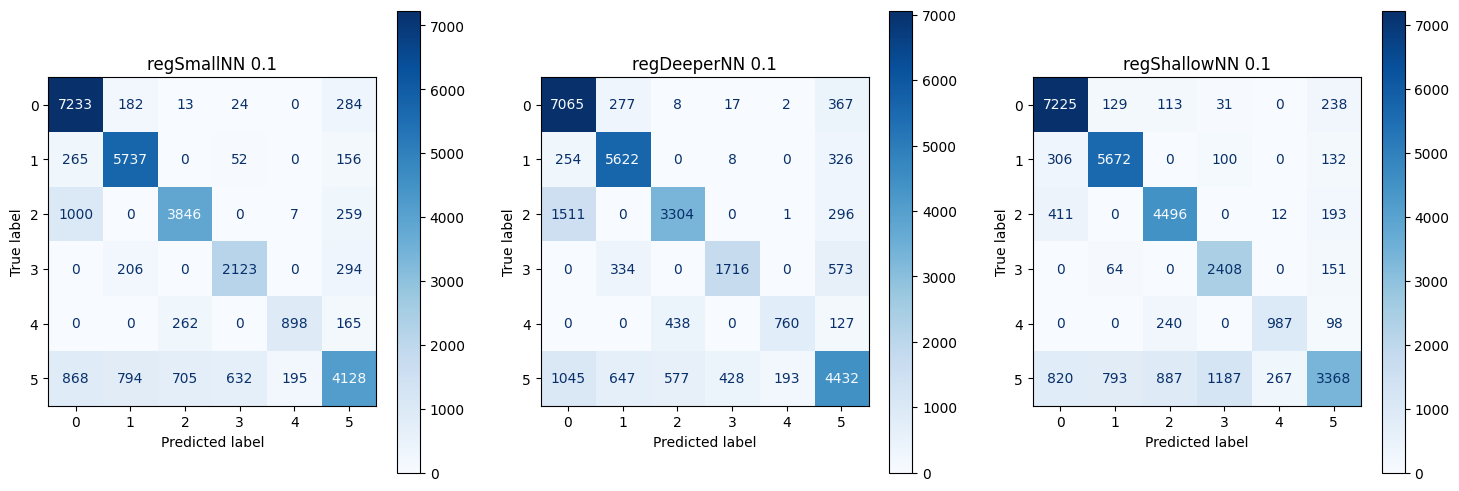

In [50]:
plot_conf_matrix(y_val, ocean_regSmallNN, ocean_regDeeperNN, ocean_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])

# WINE

In [51]:
dataset_name = "wine"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

wine_smallNN = eval_net(dataset_name, 'model1')
wine_deeperNN = eval_net(dataset_name, 'model2')
wine_shallowNN = eval_net(dataset_name, 'model3')

wine_regSmallNN = eval_net(dataset_name, 'model1r')
wine_regDeeperNN = eval_net(dataset_name, 'model2r')
wine_regShallowNN = eval_net(dataset_name, 'model3r')

(3918, 9) (780, 9) (200, 9)


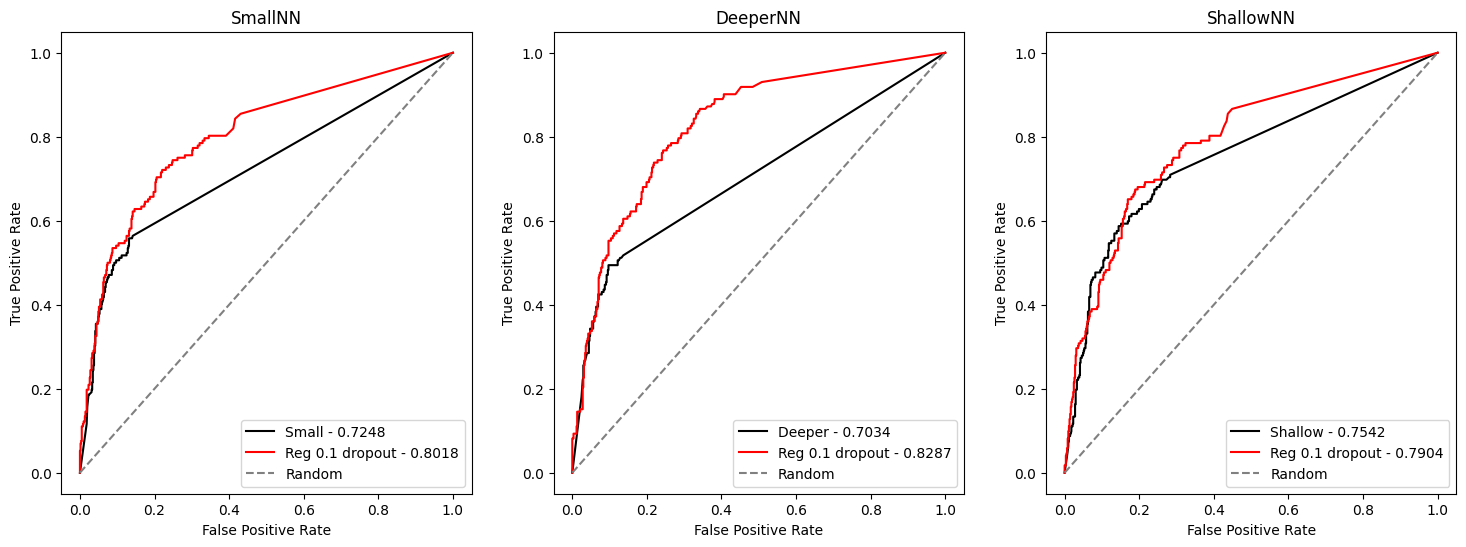

<Figure size 600x600 with 0 Axes>

In [52]:
plot_roc(y_val, wine_smallNN, wine_deeperNN, wine_shallowNN, wine_regSmallNN, wine_regDeeperNN, wine_regShallowNN, dataset_name)

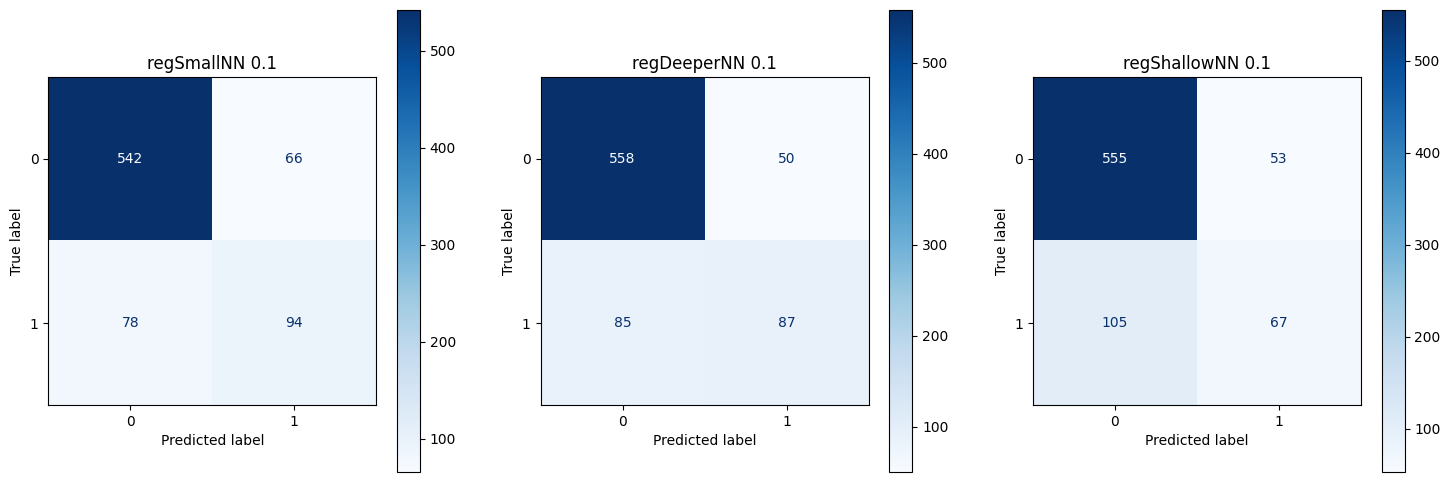

In [53]:
plot_conf_matrix(y_val, wine_regSmallNN, wine_regDeeperNN, wine_regShallowNN, title = ['regSmallNN 0.1', 'regDeeperNN 0.1', 'regShallowNN 0.1'])